In [34]:
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt

加载数据集

In [27]:
dataset=load_dataset(path="imagefolder",data_dir="./face_data")

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/500 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [29]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 500
    })
})


区分训练集、验证集和测试集

In [36]:
train_dataset=dataset["train"]
val_dataset=dataset["validation"]
test_dataset=dataset["test"]

图像展示

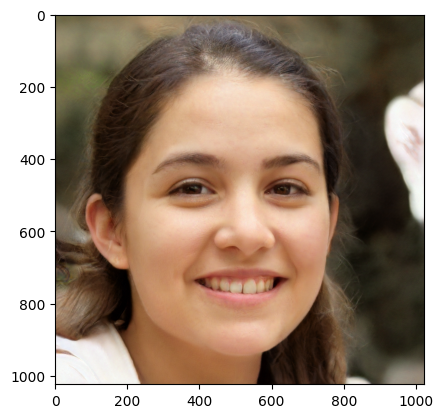

In [38]:
plt.imshow(val_dataset['image'][0])
plt.show()

定义数据增强过程

In [67]:
from torchvision import transforms

preprocess=transforms.Compose(
    [
        transforms.Resize((512,512)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5],[0.5])
        
    ]
)

定义将数据增强应用到数据集的方法

In [75]:
def transform(examples):
    images=[preprocess(image.convert("RGB")) for image in examples['image']]
    return {"image":images}


在对应数据集中应用数据增强方法

In [76]:
train_dataset.set_transform(transform)
val_dataset.set_transform(transform)

数据增强效果展示

In [77]:
print(val_dataset['image'][0].shape)

torch.Size([3, 512, 512])


将数据划分为一个一个batch

In [78]:
import torch

train_dataloader=torch.utils.data.DataLoader(train_dataset,batch_size=4,shuffle=True)

划分结果展示

In [82]:
for batch in train_dataloader:
    print(batch['image'].shape)
    break

torch.Size([4, 3, 512, 512])


In [83]:
import os
import torchvision
from torchvision.models import resnet50

# 修改预训练权重的下载地址不在C盘中
os.environ['TORCH_HOME']="./torch_model"
model=torchvision.models.resnet50(pretrained=True)

C:\Users\Shipu\anaconda3\envs\diffusers_use\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Shipu\anaconda3\envs\diffusers_use\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [84]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [85]:
for i in train_dataloader:
    out_put=model(i['image'])
    break

In [86]:
print(out_put.shape)

torch.Size([4, 1000])
